**Justificación de la métrica que elegimos: RMSE**

Para este trabajo debemos escoger una métrica para evaluar que tan bien funciona nuestro modelo de predicción. Antes de esto, pusimos a prueba el modelo con la métrica MAE y RMSE ya que las dos nos pueden indicar que tanto se equivocó nuestro modelo al predecir. Al final decidimos escoger RMSE porque esta se puede decir que es más fácil de ser entendida o de ser interpretada ya que está en las mismas unidades que la predicción, es decir estamos prediciendo el retorno del día siguiente en porcentaje y el RMSE también está en porcentaje, entonces esto nos indica de manera muy clara en cuanto nos estamos equivocando. Adicional también podemos decir que la RMSE castiga errores grandes y esto es algo super importante en este caso porque estamos trabajando con datos financieros. En un contexto de inversión de dinero podríamos decir que si nuestro modelo se equivoca poco puede que no pase mucho, pero si por el contrario nuestro modelo se equivoca mucho sería algo grave y es por esto que decidimos que nuestro modelo sea más cuidadoso con los errores grandes y la RMSE nos ayuda a medir esto y nos brinda una mayor confianza.





In [20]:
!pip install yfinance scikit-learn --quiet


In [2]:
# Importar librerías
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Descargar datos de Samsung Electronics y del índice KOSPI
samsung = yf.Ticker("005930.KS")
kospi = yf.Ticker("^KS11")

samsung_df = samsung.history(period="5y")
kospi_df = kospi.history(period="5y")

In [6]:
print(df.columns)


Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits',
       'daily_return', 'rolling_mean_20', 'rolling_std_20', 'volatility_20',
       'kospi_return'],
      dtype='object')


In [7]:
# Crear DataFrame con variables financieras
df = samsung_df.copy()
df["daily_return"] = df["Close"].pct_change()
df["rolling_mean_20"] = df["Close"].rolling(window=20).mean()
df["rolling_std_20"] = df["Close"].rolling(window=20).std()
df["volatility_20"] = df["daily_return"].rolling(window=20).std()

kospi_df["return"] = kospi_df["Close"].pct_change()
df["kospi_return"] = kospi_df["return"].values[:len(df)]

In [8]:
# Variable objetivo: retorno del siguiente día
df["target"] = df["daily_return"].shift(-1)
df["target_volatility"] = df["volatility_20"].shift(-1)

In [9]:
# Limpiar datos nulos
df = df.dropna()

In [12]:
# Entrenamiento y evaluación del modelo
feature_cols = [
    "daily_return", "rolling_mean_20", "rolling_std_20",
    "volatility_20", "kospi_return",
]
X = df[feature_cols]
y = df["target"]

In [13]:
# Separar datos de entrenamiento y prueba
split_index = int(0.8 * len(df))
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [14]:
# Entrenar modelo
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [15]:
# Predecir y evaluar
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

In [16]:
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")


RMSE: 0.0222
MAE: 0.0166


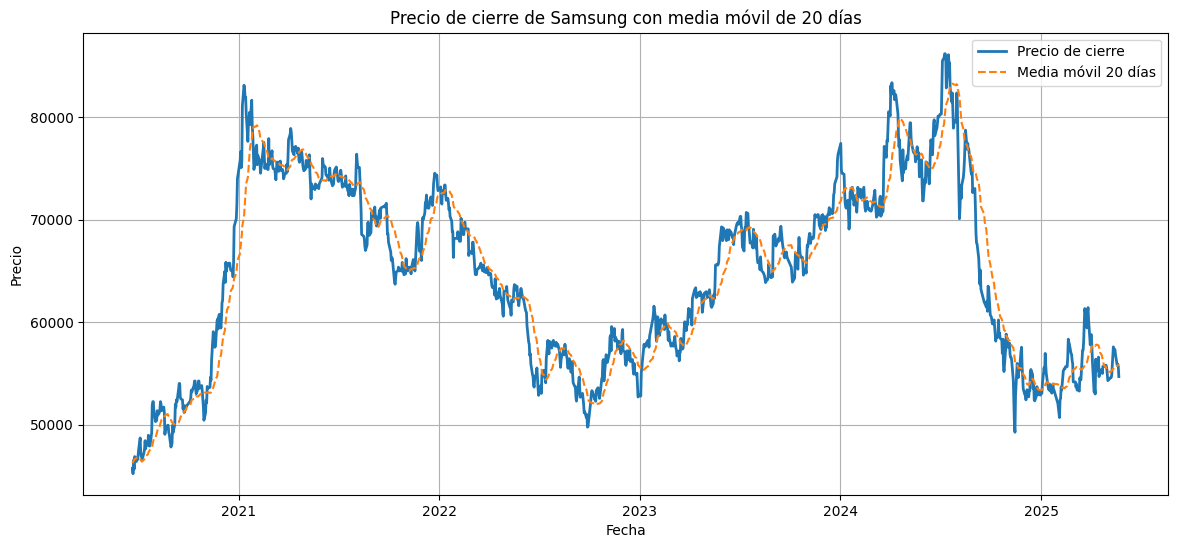

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(df["Close"], label="Precio de cierre", linewidth=2)
plt.plot(df["rolling_mean_20"], label="Media móvil 20 días", linestyle="--")
plt.title("Precio de cierre de Samsung con media móvil de 20 días")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)
plt.show()


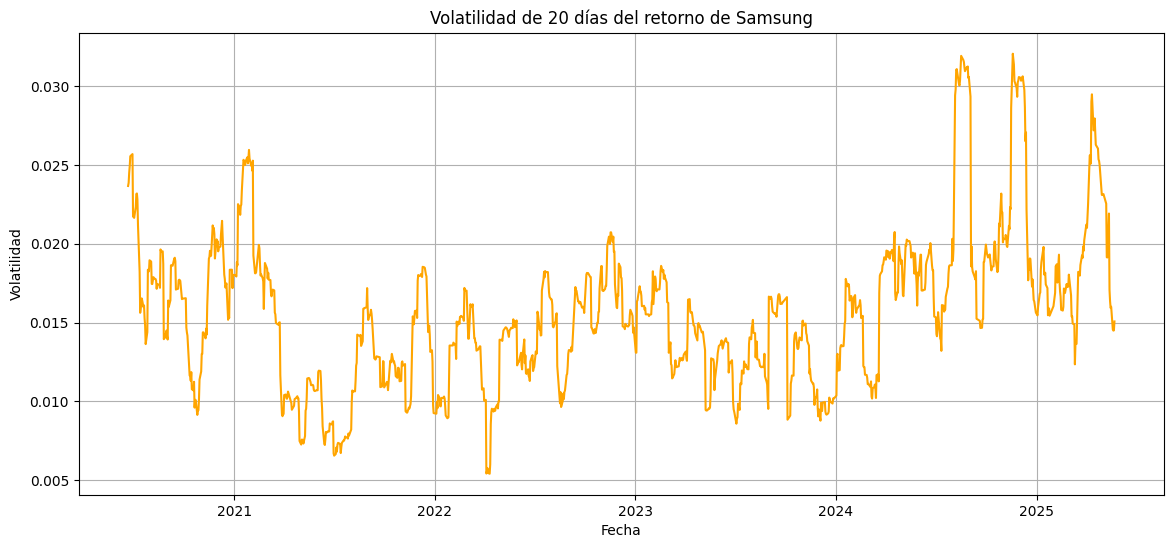

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(df["volatility_20"], color='orange')
plt.title("Volatilidad de 20 días del retorno de Samsung")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad")
plt.grid(True)
plt.show()


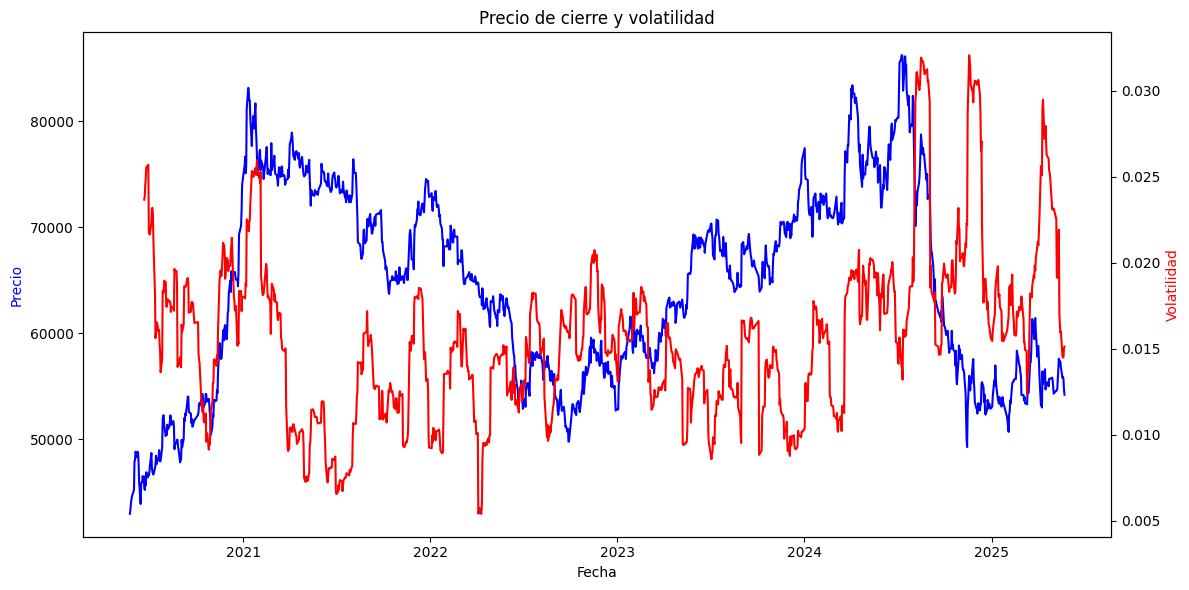

In [48]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df.index, df["Close"], color='blue', label='Precio de cierre')
ax2 = ax1.twinx()
ax2.plot(df.index, df["volatility_20"], color='red', label='Volatilidad 20 días')

ax1.set_xlabel("Fecha")
ax1.set_ylabel("Precio", color='blue')
ax2.set_ylabel("Volatilidad", color='red')
plt.title("Precio de cierre y volatilidad")
fig.tight_layout()
plt.show()


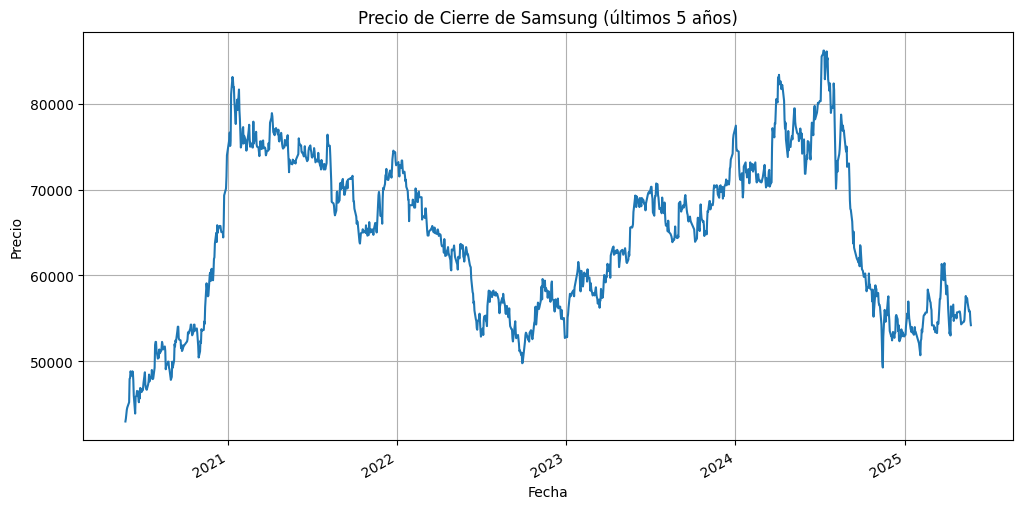

In [49]:
df["Close"].plot(figsize=(12, 6), title="Precio de Cierre de Samsung (últimos 5 años)")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid(True)
plt.show()


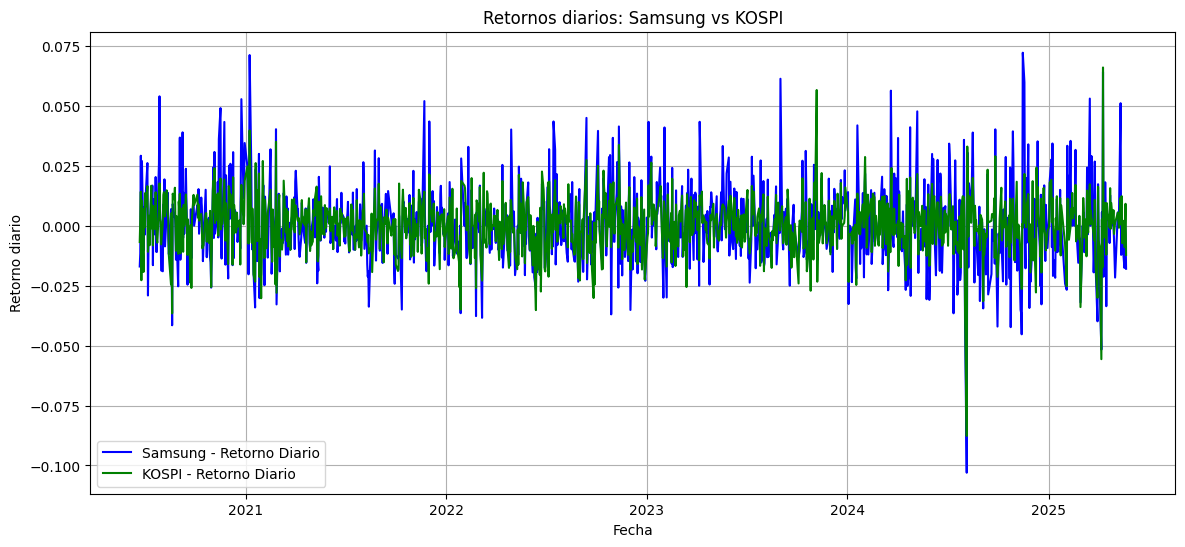

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["daily_return"], label="Samsung - Retorno Diario", color="blue")
plt.plot(df.index, df["kospi_return"], label="KOSPI - Retorno Diario", color="green")
plt.title("Retornos diarios: Samsung vs KOSPI")
plt.xlabel("Fecha")
plt.ylabel("Retorno diario")
plt.legend()
plt.grid(True)
plt.show()
